# SolarEdge Environment - Sistema di Gestione Energia con Reinforcement Learning

## Documentazione Environment

### Descrizione del Sistema

**SolarEdgeEnv** è un ambiente di simulazione Gymnasium che modella un nodo edge IoT alimentato a energia solare con batteria integrata. Il sistema deve gestire un flusso continuo di dati (frame) bilanciando:

- **Carico di lavoro**: Arrivo e processamento frame
- **Energia disponibile**: Ricarica solare e consumo batteria
- **Latenza**: Backlog dei frame da processare
- **Cooperazione**: Offload a nodi vicini

### Parametri Fisici (MODEL 1)

- **Capacità batteria**: 160 kJ
- **Potenza idle**: 2.5 W (modalità attiva)
- **Potenza sleep**: 0.1 W (modalità risparmio energetico)
- **Energia per processare frame**: 1.25 J
- **Energia per memorizzare frame**: 0.26 J
- **Energia trasmissione/ricezione**: 0.005 J
- **Rate arrivo frame (λ)**: 8 FPS
- **Rate processamento (μ)**: 10 FPS
- **Potenza solare picco**: 20 W

### Modello Solare

L'energia solare segue un pattern sinusoidale giornaliero:
- Attiva dalle 6:00 alle 18:00
- Picco a mezzogiorno
- Formula: `P(t) = P_peak × sin(π × (h - 6) / 12)` per 6 ≤ h ≤ 18

### Spazio delle Azioni

L'agente può scegliere 4 azioni:

0. **STORE**: Memorizza frame nel backlog (consumo minimo)
1. **PROCESS**: Elabora attivamente i frame (consumo medio)
2. **OFFLOAD_N1**: Invia frame al primo nodo vicino (consumo trasmissione)
3. **OFFLOAD_N2**: Invia frame al secondo nodo vicino (consumo trasmissione)

### Spazio delle Osservazioni

Vettore di 7 elementi normalizzati [0,1]:

1. **battery_frac**: Livello batteria corrente / capacità massima
2. **backlog_frac**: Frame in coda / massimo backlog
3. **hour_sin**: sin(2π × ora/24) - componente ciclica oraria
4. **hour_cos**: cos(2π × ora/24) - componente ciclica oraria
5. **solar_power_frac**: Potenza solare istantanea / picco
6. **neighbor1_load**: Carico del vicino 1 (0-1)
7. **neighbor2_load**: Carico del vicino 2 (0-1)

### Sistema di Reward

Il reward è progettato per ottimizzare l'efficienza complessiva:

**Componenti positive**:
- `+1.0` per ogni frame processato (PROCESS)
- `+0.8` per frame offloadato con successo
- `+1.0` per background processing durante sleep (efficienza energetica)

**Penalità**:
- `-10.0` per entrare in sleep mode (prima volta)
- `-5.0` per ogni step in sleep mode (dopo il primo)
- `-0.1` per ogni frame in backlog (pressione latenza)
- `-20.0` per frame droppati (backlog overflow)

### Dinamiche del Sistema

**Arrivo Frame**: Processo di Poisson con rate λ = 8 FPS

**Processamento**:
- Active mode: μ = 10 FPS
- Sleep mode: μ_bg = 0.5 FPS (background processing ridotto)

**Gestione Energia**:
- Ricarica solare ogni secondo
- Consumo continuo (idle/sleep) + consumo per azione
- Batteria scarica → forzatura sleep mode
- Safety margin: 5 J riservati per evitare shutdown

**Vicini**:
- Simulati con carico dinamico [0-1]
- Accettano offload solo se carico < soglia
- Evoluzione temporale realistica del carico

### Terminazione Episodio

- Raggiungimento tempo simulazione (es. 24 ore)
- Batteria completamente scarica senza possibilità di ricarica

---

## Modalità di Test

### 1. Policy Random
Selezione casuale uniforme tra le 4 azioni disponibili. Baseline per confronto.

### 2. Policy Euristica (Threshold-Based)
Logica deterministica basata su soglie:
- **Batteria critica** (< 20%): STORE (risparmio energetico)
- **Backlog alto** (> 70%) + energia sufficiente: PROCESS (riduzione latenza)
- **Backlog medio** (30-70%):
  - Energia alta (> 60%): PROCESS
  - Energia bassa: OFFLOAD al vicino meno carico
- **Backlog basso** (< 30%):
  - Energia molto bassa (< 30%): STORE
  - Altrimenti: PROCESS moderato

### 3. Policy Machine Learning (PPO)
Proximal Policy Optimization addestrata su:
- Orizzonte temporale lungo (24 ore = ~700k step)
- Reward shaping per efficienza energetica
- Esplorazione controllata per pattern ottimali

**Vantaggi PPO**:
- Apprende correlazioni non lineari tra stato e azioni
- Ottimizza strategia a lungo termine
- Adattamento ai pattern solari e di carico

---

## 1. Installazione Dipendenze

In [ ]:
!pip install stable-baselines3 gymnasium shimmy matplotlib pandas numpy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.2 MB/s eta 0:00:00


---

## 2. Definizione Environment

In [ ]:
from __future__ import annotations
import math
import random
from typing import List, Optional, Dict, Tuple

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import pandas as pd

# Parametri fisici del modello
MOD_1_PARAMS = {
    "battery_capacity": 160000.0,  # J (160 kJ)
    "idle_power": 2.5,             # W (Active)
    "sleep_power": 0.1,            # W (Deep Sleep)
    "energy_process": 1.25,        # J per frame
    "energy_store": 0.26,          # J per frame
    "energy_tx_rx": 0.005,         # J per trasmissione
    "lambda_rate": 8.0,            # FPS arrivo
    "mu_rate": 10.0,               # FPS processamento
    "solar_peak_power": 20.0       # W picco solare
}

# ID Azioni
ACTION_STORE = 0
ACTION_PROCESS = 1
# >= 2 -> Offload

def solar_power_model(t_sec: float, peak_power: float) -> float:
    """Modello sinusoidale energia solare giornaliera"""
    seconds_in_day = 24 * 3600
    t_in_day = t_sec % seconds_in_day
    hours = t_in_day / 3600.0

    # Notte: nessuna energia solare
    if hours < 6.0 or hours > 18.0:
        return 0.0

    # Giorno: pattern sinusoidale
    solar_angle = np.pi * (hours - 6.0) / 12.0
    return np.sin(solar_angle) * peak_power

def generate_solar_trace_seconds(total_seconds: int, peak_power: float) -> np.ndarray:
    """Genera traccia completa energia solare per simulazione"""
    t = np.arange(total_seconds, dtype=float)
    v_solar_power = np.vectorize(solar_power_model)
    return v_solar_power(t, peak_power).astype(np.float32)


class SolarEdgeEnv(gym.Env):
    """Environment Gymnasium per nodo edge con energia solare e Sleep Forzato"""

    metadata = {"render_modes": ["human"], "render_fps": 4}

    def __init__(
        self,
        *,
        seed: Optional[int] = None,
        sim_seconds: int = 24 * 3600,  # 24 ore default
        num_neighbors: int = 2,
        avg_arrival_rate: float = MOD_1_PARAMS["lambda_rate"],
        battery_capacity_j: float = MOD_1_PARAMS["battery_capacity"],
        P0: float = MOD_1_PARAMS["idle_power"],
        sleep_power: float = MOD_1_PARAMS["sleep_power"],
        mu: float = MOD_1_PARAMS["mu_rate"],
        zeta_j: float = MOD_1_PARAMS["energy_process"],
        xi_j: float = MOD_1_PARAMS["energy_tx_rx"],
        store_cost_j: float = MOD_1_PARAMS["energy_store"],
        solar_peak_power: float = MOD_1_PARAMS["solar_peak_power"],
        harvest_trace: Optional[np.ndarray] = None,
        initial_battery_j: Optional[float] = None,
        random_init_battery: bool = False,
        min_init_battery_frac: float = 0.25,
        backlog_max: int = 120000,
        time_step_max_seconds: float = 3600.0,
        random_start: bool = True,
        critical_battery_frac: float = 0.05  # 5% soglia critica
    ):
        super().__init__()

        self.rng = np.random.RandomState(seed)
        self.seed_val = seed
        self.sim_seconds = sim_seconds
        self.num_neighbors = num_neighbors

        # Parametri energetici
        self.avg_arrival_rate = avg_arrival_rate
        self.battery_capacity_j = battery_capacity_j
        self.P0 = P0
        self.sleep_power = sleep_power
        self.mu = mu
        self.zeta_j = zeta_j
        self.xi_j = xi_j
        self.store_cost_j = store_cost_j
        self.solar_peak_power = solar_peak_power
        self.backlog_max = backlog_max
        self.time_step_max_seconds = time_step_max_seconds

        # Soglia critica per sleep automatico (es. 10% della batteria)
        self.critical_battery_j = battery_capacity_j * critical_battery_frac

        # Inizializzazione batteria
        self.random_init_battery = random_init_battery
        self.min_init_battery_frac = min_init_battery_frac
        if initial_battery_j is not None:
            self.initial_battery_j = initial_battery_j
        else:
            self.initial_battery_j = 1 * self.battery_capacity_j

        self.random_start = random_start

        # Traccia energia solare
        if harvest_trace is not None:
            self.harvest_trace = harvest_trace
        else:
            self.harvest_trace = generate_solar_trace_seconds(
                self.sim_seconds, self.solar_peak_power
            )

        # Spazi Gymnasium
        # Osservazione: [battery_frac, backlog_frac, hour_sin, hour_cos,
        #                solar_power_frac, neighbor1_load, neighbor2_load]
        obs_dim = 7
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(obs_dim,), dtype=np.float32
        )

        # Azioni: 0=STORE, 1=PROCESS, 2..N+1=OFFLOAD
        self.action_space = spaces.Discrete(2 + self.num_neighbors)

        # Variabili di stato
        self.t = 0
        self.battery_j = 0.0
        self.backlog = 0
        self.sleep_mode = False # True se in sleep forzato
        self.is_dead = False    # True se batteria a 0
        self.neighbor_loads = np.zeros(self.num_neighbors, dtype=np.float32)
        self.neighbor_batteries = np.zeros(self.num_neighbors, dtype=np.float32)

        # Statistiche
        self.total_frames_arrived = 0
        self.total_frames_processed = 0
        self.total_frames_dropped = 0
        self.total_frames_offloaded = 0
        self.sleep_steps = 0

        # Storia per plotting
        self.history = {
            'time': [],
            'battery': [],
            'backlog': [],
            'action': [],
            'solar_power': [],
            'sleep_mode': [],
            'is_dead': []
        }

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.RandomState(seed)

        # Inizializzazione tempo
        if self.random_start:
            self.t = self.rng.randint(0, self.sim_seconds)
        else:
            self.t = 0

        # Inizializzazione batteria
        if self.random_init_battery:
            frac = self.rng.uniform(self.min_init_battery_frac, 1.0)
            self.battery_j = frac * self.battery_capacity_j
        else:
            self.battery_j = self.initial_battery_j

        self.backlog = 0
        self.sleep_mode = False
        self.is_dead = False
        self.neighbor_loads = self.rng.uniform(0.2, 0.7, size=self.num_neighbors).astype(np.float32)
        self.neighbor_batteries = self.rng.uniform(0.5, 1.0, size=self.num_neighbors).astype(np.float32)

        # Reset statistiche
        self.total_frames_arrived = 0
        self.total_frames_processed = 0
        self.total_frames_dropped = 0
        self.total_frames_offloaded = 0
        self.sleep_steps = 0

        # Reset storia
        self.history = {
            'time': [],
            'battery': [],
            'backlog': [],
            'action': [],
            'solar_power': [],
            'sleep_mode': [],
            'is_dead': []
        }

        obs = self._get_obs()
        info = self._get_info()
        return obs, info

    def step(self, action: int):
        """Esegue un passo di simulazione"""

        # 1. Arrivo frame (Poisson)
        arrivals = self.rng.poisson(self.avg_arrival_rate)
        self.total_frames_arrived += arrivals

        # Inizializziamo 'dropped' qui per contare sia i drop da sleep che da overflow
        dropped = 0

        if self.sleep_mode:
            # SE IN SLEEP: I frame vengono droppati subito e NON entrano nel backlog
            dropped = arrivals
            self.total_frames_dropped += arrivals
        else:
            # ALTRIMENTI: Si accumulano nel backlog
            self.backlog += arrivals

        # 2. Gestione overflow backlog (Drop packets)
        # Controlliamo se il backlog (aggiornato solo se non eravamo in sleep) supera il max
        if self.backlog > self.backlog_max:
            overflow = self.backlog - self.backlog_max
            self.backlog = self.backlog_max

            # Aggiungiamo l'overflow ai frame già eventualmente droppati per sleep
            dropped += overflow
            self.total_frames_dropped += overflow

        # 3. Ricarica solare (Prima del consumo!)
        solar_idx = self.t % len(self.harvest_trace)
        solar_power_w = float(self.harvest_trace[solar_idx])
        harvest_j = solar_power_w * 1.0  # 1 secondo

        # Aggiungiamo energia. Se eravamo a 0, questo potrebbe "resuscitarci"
        self.battery_j = min(self.battery_j + harvest_j, self.battery_capacity_j)

        # 4. Determinazione Stato Operativo (Sleep/Dead/Active)
        # Questa logica sovrascrive l'azione dell'agente se necessario

        current_action = action # L'azione che vorrebbe fare l'agente
        executed_action = -1    # L'azione effettivamente eseguita (-1: nulla/sleep)
        consumption = 0.0
        processed_now = 0
        offloaded_now = 0

        # Reset flag stato per questo step
        self.sleep_mode = False
        self.is_dead = False

        if self.battery_j <= 0.001:
            # CASO 1: Batteria MORTA (circa 0)
            # Il nodo è spento. Non consuma (o trascurabile), non processa.
            self.is_dead = True
            self.battery_j = 0.0
            consumption = 0.0
            # Nessuna azione possibile
            executed_action = -99 # Code for DEAD

        elif self.battery_j < self.critical_battery_j:
            # CASO 2: Batteria CRITICA (< 10%) -> FORCED SLEEP
            # Il nodo entra automaticamente in sleep. L'azione dell'agente è ignorata.
            self.sleep_mode = True
            self.sleep_steps += 1
            consumption = self.sleep_power * 1.0 # Consumo minimo
            executed_action = -1 # Code for SLEEP

            # Opzionale: Se vuoi che in sleep processi qualcosa molto lentamente:
            # if self.backlog > 0: ...
            # Per ora assumiamo sleep puro (solo idle cost ridotto)

        else:
            # CASO 3: Batteria OK -> ACTIVE
            # L'agente può agire. Paghiamo il costo IDLE standard + costo azione
            consumption = self.P0 * 1.0
            executed_action = current_action

            # Esecuzione logica azione
            if current_action == ACTION_STORE:
                # Solo idle cost (già aggiunto), più costo store se definito
                consumption += self.store_cost_j

            elif current_action == ACTION_PROCESS:
                if self.backlog > 0:
                    frames_to_process = min(int(self.mu), self.backlog)
                    proc_cost = self.zeta_j * frames_to_process

                    # Verifichiamo se abbiamo energia per processare QUESTO blocco
                    if (self.battery_j - consumption - proc_cost) >= 0:
                        consumption += proc_cost
                        self.backlog -= frames_to_process
                        processed_now = frames_to_process
                        self.total_frames_processed += frames_to_process

            else:
                # OFFLOAD (Action >= 2)
                # Invece di usare (current_action - 2), calcoliamo il migliore dinamicamente
                neighbor_idx = self._get_best_neighbor()

                if 0 <= neighbor_idx < self.num_neighbors:
                    neighbor_load = self.neighbor_loads[neighbor_idx]

                    # Logica standard di offloading
                    if neighbor_load < 0.8 and self.backlog > 0:
                        frames_to_offload = min(int(self.mu * 0.5), self.backlog)
                        tx_cost = self.xi_j * frames_to_offload

                        if (self.battery_j - consumption - tx_cost) >= 0:
                            consumption += tx_cost
                            self.backlog -= frames_to_offload
                            offloaded_now = frames_to_offload
                            self.total_frames_offloaded += frames_to_offload

        # 5. Applicazione Consumo Energetico
        self.battery_j -= consumption

        # Safety clamp: la batteria non può andare sotto zero
        if self.battery_j < 0:
            self.battery_j = 0.0
            self.is_dead = True # È morto durante questo step

        # 6. Calcolo Reward

        # 1. Guadagno per lavoro svolto
        # Offload vale un po' meno per incentivare il processing locale quando possibile
        r_work = (processed_now * 1.0) + (offloaded_now * 0.9)

        # 2. Penalità Drop (Molto alta, deve essere inaccettabile perdere dati)
        r_drop = -1.0 * dropped

        # 3. Penalità "Battery Anxiety" (Shaping Non-Lineare)
        # SoC = State of Charge (0.0 a 1.0)
        soc = self.battery_j / self.battery_capacity_j
        # Curva polinomiale: piatta sopra il 60%, ripida sotto il 30%
        # Se soc scende, questa penalità cresce drasticamente.
        r_energy_anxiety = -20.0 * ((1.0 - soc) ** 4)

        # 4. Penalità Backlog (Queue Pressure)
        # Scoraggia l'accumulo eccessivo, incentiva a smaltire
        backlog_frac = self.backlog / self.backlog_max
        r_backlog = -2.0 * (backlog_frac ** 2)

        # 5. Penalità Eventi Critici
        r_critical = 0.0
        if self.is_dead:
            r_critical -= 100.0  # Morte = Disastro
        elif self.sleep_mode: # Forced sleep
            r_critical -= 1.0    # Forced sleep = Fallimento pianificazione

        # Somma totale
        reward = r_work + r_drop + r_energy_anxiety + r_backlog + r_critical

        # Normalizzazione opzionale (scala la reward per stabilità PPO)
        reward = reward * 0.1

        # 7. Aggiornamento Ambiente
        self._update_neighbors()

        self.history['time'].append(self.t)
        self.history['battery'].append(self.battery_j)
        self.history['backlog'].append(self.backlog)
        self.history['action'].append(executed_action)
        self.history['solar_power'].append(solar_power_w)
        self.history['sleep_mode'].append(self.sleep_mode)
        self.history['is_dead'].append(self.is_dead)

        self.t += 1

        # 8. Terminazione
        # MODIFICA IMPORTANTE: Non termina più se battery == 0.
        # Termina solo se il tempo è finito.
        terminated = (self.t >= self.sim_seconds)
        truncated = False

        obs = self._get_obs()
        info = self._get_info()

        return obs, reward, terminated, truncated, info

    def _update_neighbors(self):
        """Aggiorna carico e batteria dei vicini (simulazione)"""
        for i in range(self.num_neighbors):
            # Aggiorna Load
            delta_load = self.rng.uniform(-0.05, 0.05)
            self.neighbor_loads[i] = np.clip(self.neighbor_loads[i] + delta_load, 0.0, 1.0)

            # [NUOVO] Aggiorna Batteria (simula consumo/ricarica)
            delta_batt = self.rng.uniform(-0.02, 0.02)
            self.neighbor_batteries[i] = np.clip(self.neighbor_batteries[i] + delta_batt, 0.0, 1.0)

    def _get_best_neighbor(self) -> int:
        """Seleziona il nodo con il miglior rapporto Batteria / Backlog"""
        best_idx = -1
        best_score = -1.0

        for i in range(self.num_neighbors):
            # Recupera dati del vicino i-esimo
            bat = self.neighbor_batteries[i]
            load = self.neighbor_loads[i]

            # Evitiamo divisione per zero: se load è 0, mettiamo un valore piccolissimo
            safe_load = max(load, 0.001)

            # Calcolo Score: Più alto è meglio
            score = bat / safe_load

            if score > best_score:
                best_score = score
                best_idx = i

        return best_idx

    def _get_obs(self) -> np.ndarray:
        """Costruisce vettore osservazione normalizzato"""
        battery_frac = self.battery_j / self.battery_capacity_j
        backlog_frac = self.backlog / self.backlog_max

        hour_of_day = (self.t % 86400) / 3600.0
        hour_sin = np.sin(2 * np.pi * hour_of_day / 24.0)
        hour_cos = np.cos(2 * np.pi * hour_of_day / 24.0)

        solar_idx = self.t % len(self.harvest_trace)
        solar_power = float(self.harvest_trace[solar_idx])
        solar_frac = solar_power / self.solar_peak_power

        obs = np.array([
            battery_frac,
            backlog_frac,
            (hour_sin + 1) / 2,
            (hour_cos + 1) / 2,
            solar_frac,
            self.neighbor_loads[0] if self.num_neighbors > 0 else 0.0,
            self.neighbor_loads[1] if self.num_neighbors > 1 else 0.0,
        ], dtype=np.float32)

        return np.clip(obs, 0.0, 1.0)

    def _get_info(self) -> dict:
        return {
            "t": self.t,
            "battery_j": self.battery_j,
            "backlog": self.backlog,
            "sleep_mode": self.sleep_mode,
            "is_dead": self.is_dead,
            "total_processed": self.total_frames_processed,
            "total_dropped": self.total_frames_dropped,
        }

---

## 3. Test Modello Solare

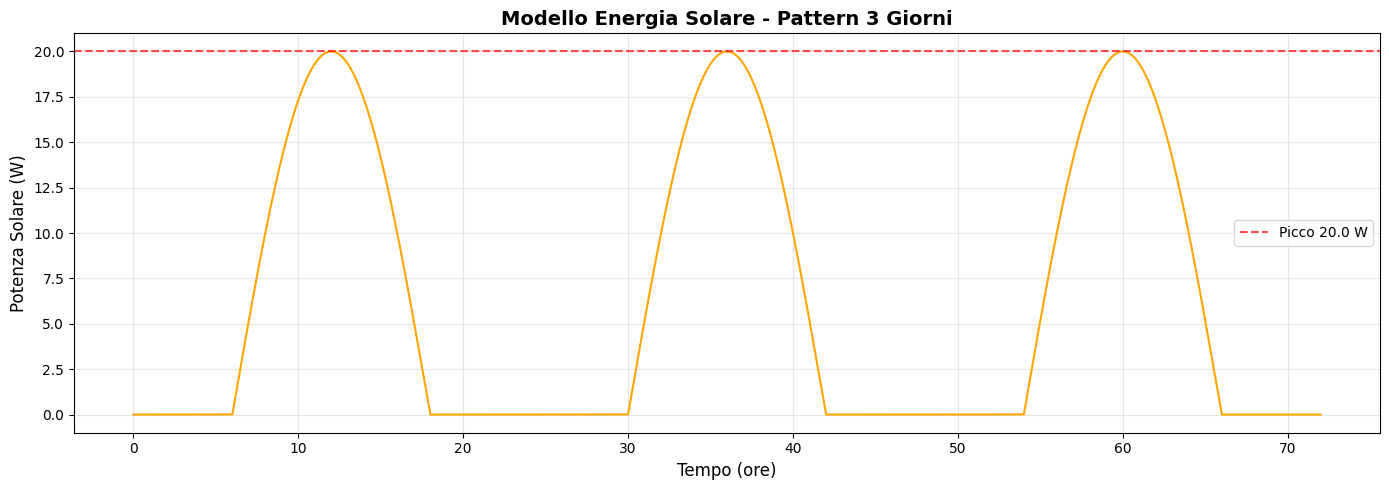

Potenza media giornaliera: 6.37 W
Energia totale giornaliera: 550.04 kJ


In [ ]:
# Genera traccia solare per 3 giorni
total_seconds = 3 * 24 * 3600
solar_trace = generate_solar_trace_seconds(total_seconds, MOD_1_PARAMS["solar_peak_power"])

# Converti in ore per plotting
hours = np.arange(len(solar_trace)) / 3600.0

plt.figure(figsize=(14, 5))
plt.plot(hours, solar_trace, linewidth=1.5, color='orange')
plt.xlabel('Tempo (ore)', fontsize=12)
plt.ylabel('Potenza Solare (W)', fontsize=12)
plt.title('Modello Energia Solare - Pattern 3 Giorni', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=MOD_1_PARAMS["solar_peak_power"], color='r', linestyle='--',
            label=f'Picco {MOD_1_PARAMS["solar_peak_power"]} W', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Potenza media giornaliera: {solar_trace[:86400].mean():.2f} W")
print(f"Energia totale giornaliera: {solar_trace[:86400].sum() / 1000:.2f} kJ")

---

## 4. Test Policy Random

In [ ]:
def test_random_policy(env, num_steps=86400):
    """Test policy completamente random"""
    obs, _ = env.reset(seed=42)

    for _ in range(num_steps):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            break

    return env

# Esegui test (2 ore di simulazione)
print("Esecuzione policy RANDOM (2 ore)...")
env_random = SolarEdgeEnv(sim_seconds=86400, random_start=False, seed=42)
env_random = test_random_policy(env_random, num_steps=86400)

# Statistiche finali
print("\n=== STATISTICHE POLICY RANDOM ===")
print(f"Frame arrivati: {env_random.total_frames_arrived}")
print(f"Frame processati: {env_random.total_frames_processed}")
print(f"Frame droppati: {env_random.total_frames_dropped}")
print(f"Frame offloadati: {env_random.total_frames_offloaded}")
print(f"Step in sleep mode: {env_random.sleep_steps}")
print(f"Batteria finale: {env_random.battery_j / 1000:.2f} kJ")
print(f"Backlog finale: {env_random.backlog}")

Esecuzione policy RANDOM (2 ore)...

=== STATISTICHE POLICY RANDOM ===
Frame arrivati: 692132
Frame processati: 213436
Frame droppati: 188461
Frame offloadati: 170235
Step in sleep mode: 0
Batteria finale: 25.79 kJ
Backlog finale: 120000


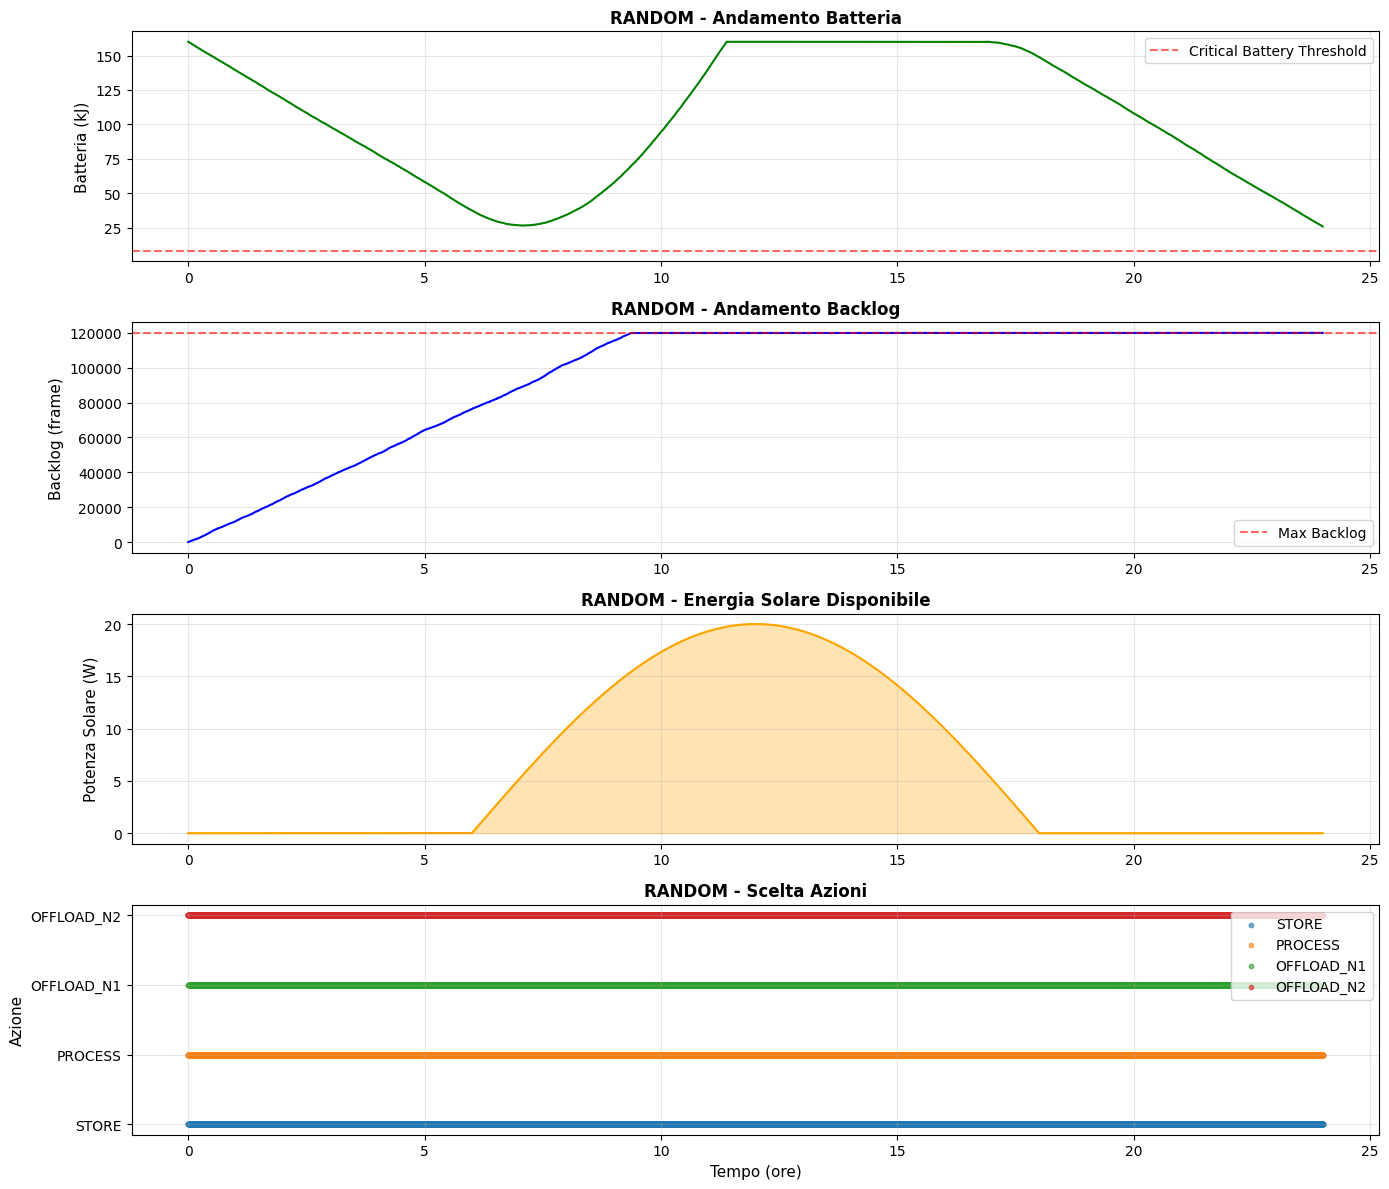

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Grafici policy random
def plot_results(env, title_prefix=""):
    """Genera grafici analisi performance"""
    history = env.history
    time_hours = np.array(history['time']) / 3600.0

    fig, axes = plt.subplots(4, 1, figsize=(14, 12))

    # Batteria
    axes[0].plot(time_hours, np.array(history['battery']) / 1000,
                 linewidth=1.5, color='green')
    axes[0].set_ylabel('Batteria (kJ)', fontsize=11)
    axes[0].set_title(f'{title_prefix}Andamento Batteria', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=env.critical_battery_j / 1000, color='r', linestyle='--', # Changed from safety_margin_j
                    label='Critical Battery Threshold', alpha=0.6) # Changed label
    axes[0].legend()

    # Backlog
    axes[1].plot(time_hours, history['backlog'], linewidth=1.5, color='blue')
    axes[1].set_ylabel('Backlog (frame)', fontsize=11)
    axes[1].set_title(f'{title_prefix}Andamento Backlog', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=env.backlog_max, color='r', linestyle='--',
                    label='Max Backlog', alpha=0.6)
    axes[1].legend()

    # Energia solare
    axes[2].plot(time_hours, history['solar_power'], linewidth=1.5, color='orange')
    axes[2].set_ylabel('Potenza Solare (W)', fontsize=11)
    axes[2].set_title(f'{title_prefix}Energia Solare Disponibile', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].fill_between(time_hours, 0, history['solar_power'], alpha=0.3, color='orange')

    # Azioni e sleep mode
    action_names = ['STORE', 'PROCESS', 'OFFLOAD_N1', 'OFFLOAD_N2']
    actions = np.array(history['action'])
    sleep_mask = np.array(history['sleep_mode'])

    # Scatter plot azioni con colori diversi
    for action_id in range(4):
        mask = (actions == action_id) & (~sleep_mask)
        if mask.any():
            axes[3].scatter(time_hours[mask], actions[mask],
                          label=action_names[action_id], alpha=0.6, s=10)

    # Evidenzia sleep mode
    if sleep_mask.any():
        axes[3].fill_between(time_hours, -0.5, 3.5,
                            where=sleep_mask, alpha=0.2, color='red',
                            label='Sleep Mode')

    axes[3].set_ylabel('Azione', fontsize=11)
    axes[3].set_xlabel('Tempo (ore)', fontsize=11)
    axes[3].set_title(f'{title_prefix}Scelta Azioni', fontsize=12, fontweight='bold')
    axes[3].set_yticks([0, 1, 2, 3])
    axes[3].set_yticklabels(action_names)
    axes[3].grid(True, alpha=0.3)
    axes[3].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_results(env_random, "RANDOM - ")

---

## 5. Policy Euristica (Threshold-Based)

Esecuzione policy EURISTICA (2 ore)...

=== STATISTICHE POLICY EURISTICA ===
Frame arrivati: 691303
Frame processati: 394749
Frame droppati: 103979
Frame offloadati: 72575
Step in sleep mode: 5587
Batteria finale: 7.58 kJ
Backlog finale: 120000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


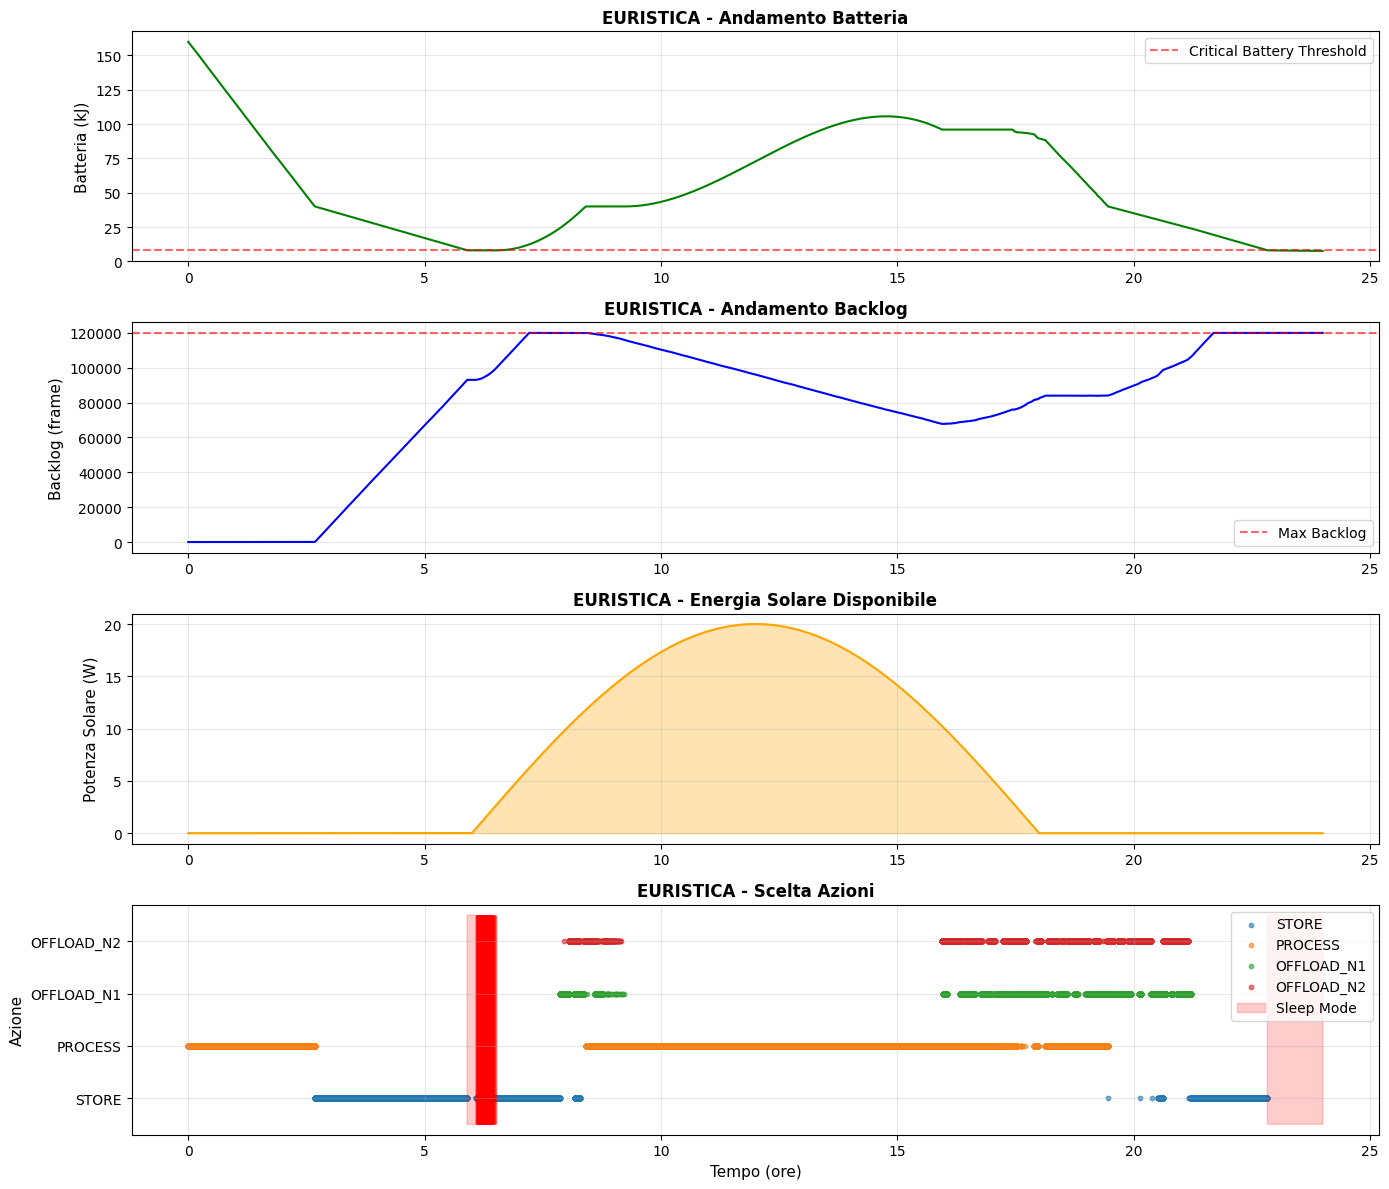

In [ ]:
def heuristic_policy(obs, env):
    """
    Policy euristica basata su soglie di batteria e backlog.

    Strategia:
    - Batteria critica: STORE (risparmio energetico)
    - Backlog alto + energia ok: PROCESS (riduzione latenza)
    - Backlog medio: bilanciamento tra PROCESS e OFFLOAD
    - Backlog basso: PROCESS conservativo o STORE se poca energia
    """
    battery_frac = obs[0]
    backlog_frac = obs[1]
    neighbor1_load = obs[5]
    neighbor2_load = obs[6]

    # Soglie critiche
    BATTERY_CRITICAL = 0.15
    BATTERY_LOW = 0.25
    BATTERY_GOOD = 0.60
    BACKLOG_HIGH = 0.70
    BACKLOG_MED = 0.30

    # Batteria critica: solo STORE
    if battery_frac < BATTERY_CRITICAL:
        return ACTION_STORE

    # Backlog molto alto: priorità PROCESS se energia ok
    if backlog_frac > BACKLOG_HIGH:
        if battery_frac > BATTERY_LOW:
            return ACTION_PROCESS
        else:
            # Offload al vicino meno carico
            if neighbor1_load < neighbor2_load and neighbor1_load < 0.8:
                return 2  # OFFLOAD_N1
            elif neighbor2_load < 0.8:
                return 3  # OFFLOAD_N2
            else:
                return ACTION_STORE

    # Backlog medio: bilanciamento
    if backlog_frac > BACKLOG_MED:
        if battery_frac > BATTERY_GOOD:
            return ACTION_PROCESS
        elif battery_frac > BATTERY_LOW:
            # Offload al vicino meno carico
            if neighbor1_load < neighbor2_load and neighbor1_load < 0.8:
                return 2
            elif neighbor2_load < 0.8:
                return 3
            else:
                return ACTION_PROCESS
        else:
            return ACTION_STORE

    # Backlog basso: conservativo
    if battery_frac < BATTERY_LOW:
        return ACTION_STORE
    else:
        return ACTION_PROCESS


def test_heuristic_policy(env, num_steps=86400):
    """Test policy euristica"""
    obs, _ = env.reset(seed=42)

    for _ in range(num_steps):
        action = heuristic_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            break

    return env

# Esegui test
print("Esecuzione policy EURISTICA (2 ore)...")
env_heuristic = SolarEdgeEnv(sim_seconds=86400, random_start=False, seed=42)
env_heuristic = test_heuristic_policy(env_heuristic, num_steps=86400)

# Statistiche
print("\n=== STATISTICHE POLICY EURISTICA ===")
print(f"Frame arrivati: {env_heuristic.total_frames_arrived}")
print(f"Frame processati: {env_heuristic.total_frames_processed}")
print(f"Frame droppati: {env_heuristic.total_frames_dropped}")
print(f"Frame offloadati: {env_heuristic.total_frames_offloaded}")
print(f"Step in sleep mode: {env_heuristic.sleep_steps}")
print(f"Batteria finale: {env_heuristic.battery_j / 1000:.2f} kJ")
print(f"Backlog finale: {env_heuristic.backlog}")

plot_results(env_heuristic, "EURISTICA - ")

---

## 6. Training Agente PPO

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.env_util import make_vec_env

# Configurazione training
# Una giornata reale = 86400 step
# Training su ~5 giorni simulati
TOTAL_TIMESTEPS = 500000  # ~432k steps

print("Inizializzazione environment per training...")

# Crea environment vettorizzato (parallelizzazione)
def make_env():
    def _init():
        return SolarEdgeEnv(
            sim_seconds=21600,  # 4 ore per episodio
            random_init_battery=True,
            min_init_battery_frac=0.25,
            random_start=True
        )
    return _init

# 4 environment paralleli per speedup
env_train = DummyVecEnv([make_env() for _ in range(4)])
env_eval = SolarEdgeEnv(
    sim_seconds=86400,
    random_init_battery=False,
    initial_battery_j=0.7 * MOD_1_PARAMS["battery_capacity"],
    random_start=False,
    seed=999
)

print("Configurazione agente PPO...")

# PPO con hyperparameter ottimizzati per lungo orizzonte
model = PPO(
    "MlpPolicy",
    env_train,
    learning_rate=3e-4,
    n_steps=2048,        # Batch size per update. #4096
    batch_size=64,       # Minibatch SGD
    n_epochs=10,         # Epoche per update
    gamma=0.9999,        # Discount factor (importante per reward futuro)
    gae_lambda=0.98,     # Generalized Advantage Estimation
    clip_range=0.2,      # PPO clip epsilon
    ent_coef=0.05,       # Entropy bonus (esplorazione) #0.05
    vf_coef=0.5,         # Value function coefficient
    max_grad_norm=0.5,   # Gradient clipping
    verbose=1,
    tensorboard_log="./ppo_solaredge_tensorboard/"
)

print(f"\nInizio training: {TOTAL_TIMESTEPS:,} timesteps totali")
print("Questo richiederà diversi minuti...\n")

Inizializzazione environment per training...
Configurazione agente PPO...
Using cpu device

Inizio training: 500,000 timesteps totali
Questo richiederà diversi minuti...



In [ ]:
# Callback per salvataggio checkpoint
checkpoint_callback = CheckpointCallback(
    save_freq=50000,
    save_path="./ppo_checkpoints/",
    name_prefix="ppo_solaredge"
)

# Training
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=checkpoint_callback,
    progress_bar=True
)

# Salva modello finale
model.save("ppo_solaredge_final")
print("\nTraining completato! Modello salvato in 'ppo_solaredge_final.zip'")

Logging to ./ppo_solaredge_tensorboard/PPO_3


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

-----------------------------
| time/              |      |
|    fps             | 5273 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 8192 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2561        |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.015211032 |
|    clip_fraction        | 0.161       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.37       |
|    explained_variance   | 0.00888     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.75        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0096     |
|    value_loss           | 40.2        |
-----------------------------------------
----------------------------------


Training completato! Modello salvato in 'ppo_solaredge_final.zip'


---

## 7. Test Agente PPO Addestrato

Esecuzione policy PPO (2 ore)...

=== STATISTICHE POLICY PPO ===
Frame arrivati: 691303
Frame processati: 409497
Frame droppati: 88150
Frame offloadati: 135472
Step in sleep mode: 10998
Batteria finale: 7.62 kJ
Backlog finale: 58184


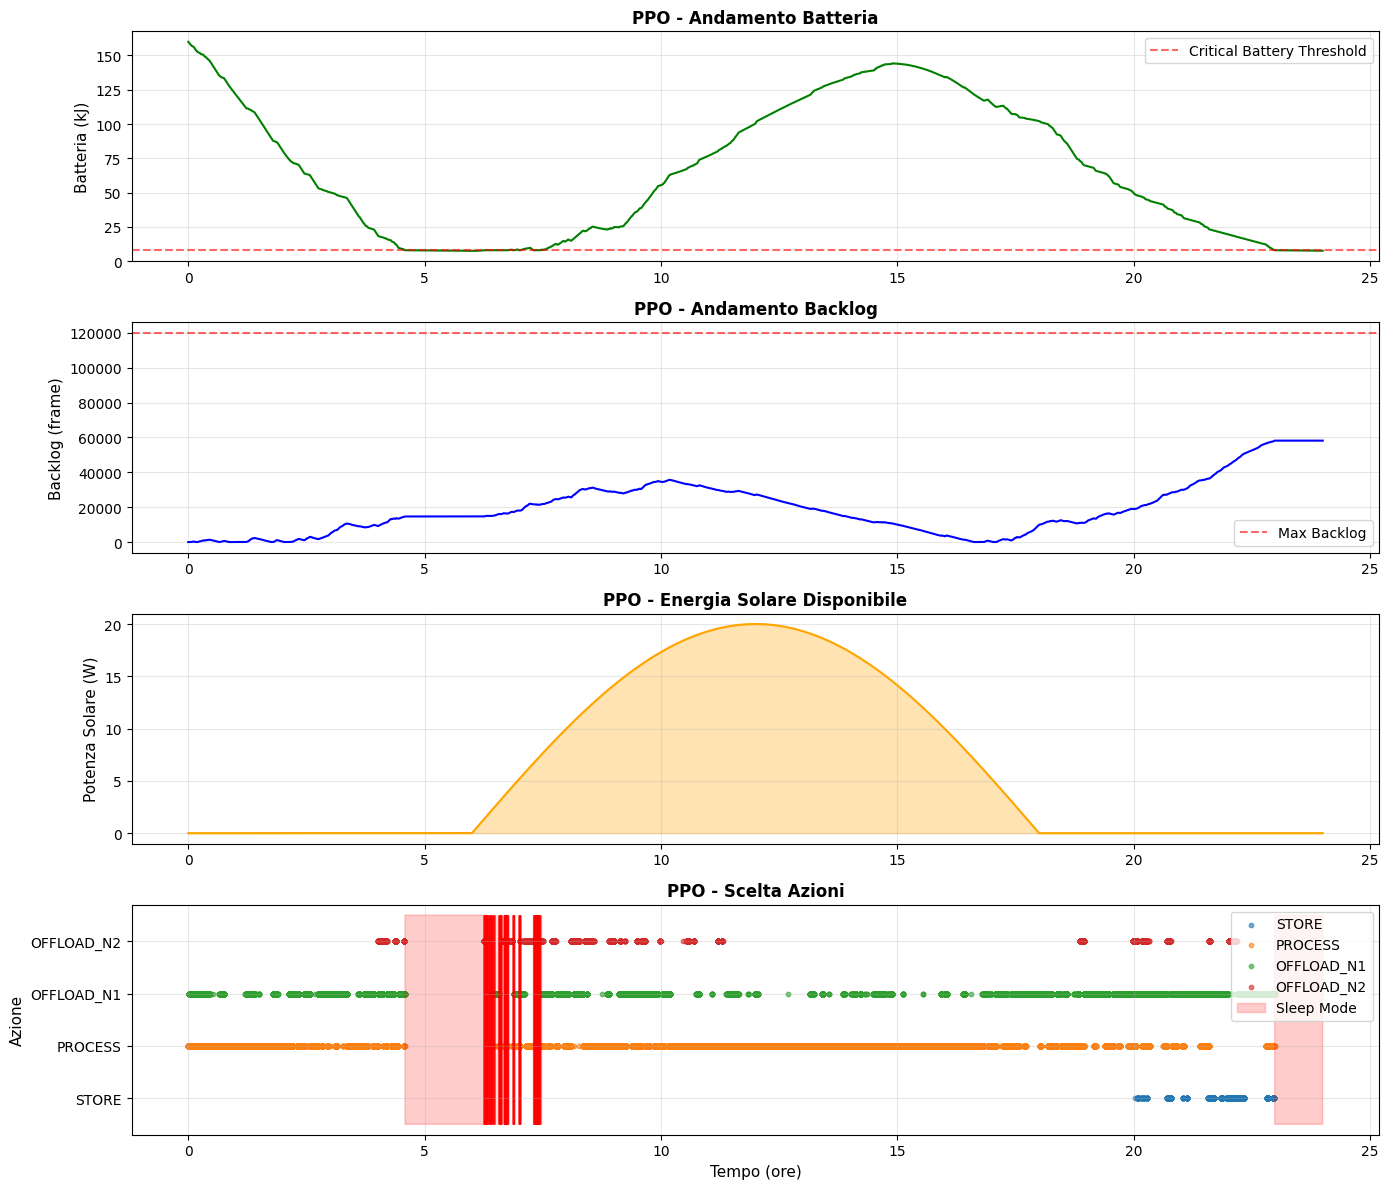

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Carica modello addestrato
model_trained = PPO.load("ppo_solaredge_final")

def test_ppo_policy(model, env, num_steps=86400, deterministic=True):
    """Test policy PPO addestrata"""
    obs, _ = env.reset(seed=42)

    for _ in range(num_steps):
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(int(action))

        if terminated or truncated:
            break

    return env

# Test su 2 ore (stesso setup degli altri)
print("Esecuzione policy PPO (2 ore)...")
env_ppo = SolarEdgeEnv(sim_seconds=86400, random_start=False, seed=42)
env_ppo = test_ppo_policy(model_trained, env_ppo, num_steps=86400)

# Statistiche
print("\n=== STATISTICHE POLICY PPO ===")
print(f"Frame arrivati: {env_ppo.total_frames_arrived}")
print(f"Frame processati: {env_ppo.total_frames_processed}")
print(f"Frame droppati: {env_ppo.total_frames_dropped}")
print(f"Frame offloadati: {env_ppo.total_frames_offloaded}")
print(f"Step in sleep mode: {env_ppo.sleep_steps}")
print(f"Batteria finale: {env_ppo.battery_j / 1000:.2f} kJ")
print(f"Backlog finale: {env_ppo.backlog}")

plot_results(env_ppo, "PPO - ")

---

## 8. Confronto Finale delle Policy


CONFRONTO PERFORMANCE POLICY
   Policy  Frame Processati  Frame Droppati  Step in Sleep  Batteria Finale (kJ)  Backlog Finale
   Random            213436          188461              0                 25.79          120000
Euristica            394749          103979           5587                  7.58          120000
      PPO            409497           88150          10998                  7.62           58184


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


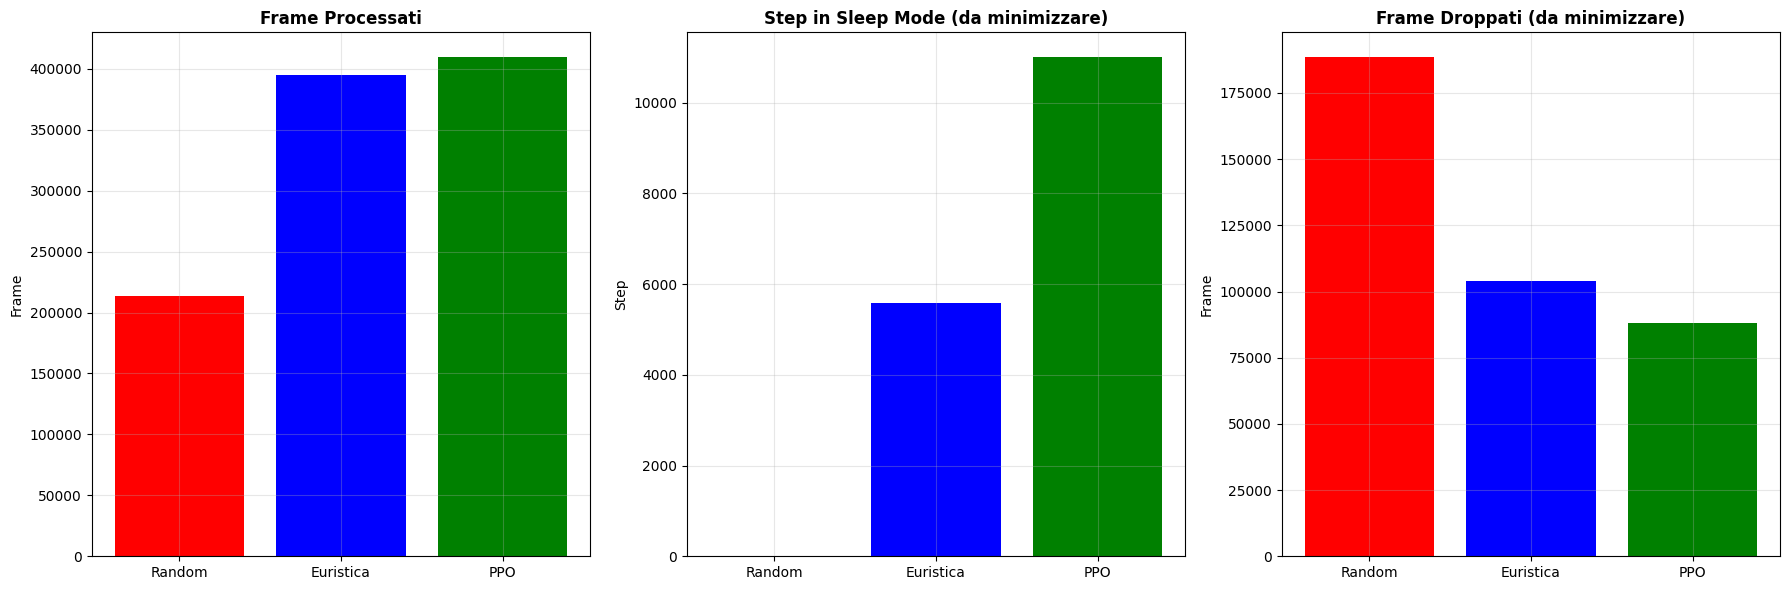

In [ ]:
# Confronto metriche
metrics = {
    'Policy': ['Random', 'Euristica', 'PPO'],
    'Frame Processati': [
        env_random.total_frames_processed,
        env_heuristic.total_frames_processed,
        env_ppo.total_frames_processed
    ],
    'Frame Droppati': [
        env_random.total_frames_dropped,
        env_heuristic.total_frames_dropped,
        env_ppo.total_frames_dropped
    ],
    'Step in Sleep': [
        env_random.sleep_steps,
        env_heuristic.sleep_steps,
        env_ppo.sleep_steps
    ],
    'Batteria Finale (kJ)': [
        env_random.battery_j / 1000,
        env_heuristic.battery_j / 1000,
        env_ppo.battery_j / 1000
    ],
    'Backlog Finale': [
        env_random.backlog,
        env_heuristic.backlog,
        env_ppo.backlog
    ]
}

df_comparison = pd.DataFrame(metrics)
print("\n" + "="*70)
print("CONFRONTO PERFORMANCE POLICY")
print("="*70)
print(df_comparison.to_string(index=False))
print("="*70)

# Grafici comparativi
# Modifica: 1 riga, 3 colonne. Aumentata la larghezza (figsize) per farli stare comodi.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

policies = ['Random', 'Euristica', 'PPO']
colors = ['red', 'blue', 'green']

# Frame processati (Indice 0)
axes[0].bar(policies, metrics['Frame Processati'], color=colors)
axes[0].set_ylabel('Frame')
axes[0].set_title('Frame Processati', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Step in sleep mode (Indice 1)
axes[1].bar(policies, metrics['Step in Sleep'], color=colors)
axes[1].set_ylabel('Step')
axes[1].set_title('Step in Sleep Mode (da minimizzare)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Frame droppati (Indice 2)
axes[2].bar(policies, metrics['Frame Droppati'], color=colors)
axes[2].set_ylabel('Frame')
axes[2].set_title('Frame Droppati (da minimizzare)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Configurazione Test: Durata 1 giorni (86400 step/secondi)
Avvio simulazione per policy: random...
Avvio simulazione per policy: heuristic...
Avvio simulazione per policy: ppo...


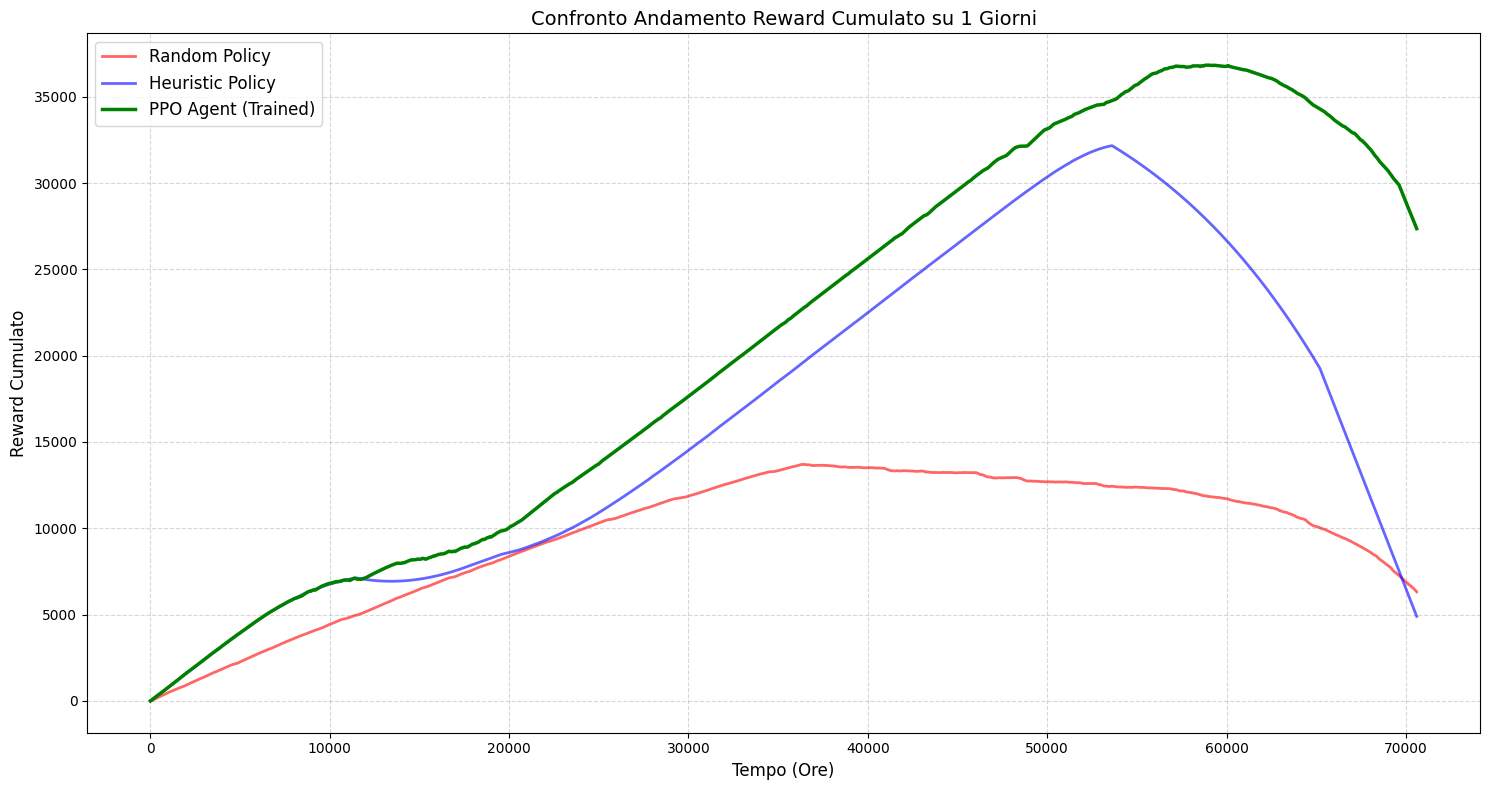

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURAZIONE DURATA ---
SIM_DAYS = 1
SIM_SECONDS = SIM_DAYS * 24 * 3600

print(f"Configurazione Test: Durata {SIM_DAYS} giorni ({SIM_SECONDS} step/secondi)")

# --- INIZIALIZZAZIONE AMBIENTE ---
env_test = SolarEdgeEnv(sim_seconds=SIM_SECONDS)

# --- FUNZIONE DI TEST ---
def run_policy_test(env, policy_type, model=None, steps=86400):
    """Esegue un episodio completo con la policy specificata"""
    obs, _ = env.reset(seed=42)
    rewards = []

    print(f"Avvio simulazione per policy: {policy_type}...")

    for i in range(steps):
        if policy_type == 'random':
            action = env.action_space.sample()
        elif policy_type == 'heuristic':
            action = heuristic_policy(obs, env)
        elif policy_type == 'ppo':
            action, _ = model.predict(obs, deterministic=True)
            action = int(action)

        obs, reward, terminated, truncated, _ = env.step(action)
        rewards.append(reward)

        if terminated or truncated:
            break

    return np.array(rewards)

# --- ESECUZIONE DELLE 3 POLICY ---

# 1. Random
rewards_random = run_policy_test(env_test, 'random', steps=SIM_SECONDS)

# 2. Euristica
rewards_heuristic = run_policy_test(env_test, 'heuristic', steps=SIM_SECONDS)

# 3. PPO (Agente Trainato)
if 'model_trained' in globals():
    rewards_ppo = run_policy_test(env_test, 'ppo', model=model_trained, steps=SIM_SECONDS)
else:
    print("ERRORE: 'model_trained' non trovato. Esegui la cella di caricamento modello prima di questa.")
    rewards_ppo = np.zeros(len(rewards_random))

# --- CALCOLO REWARD CUMULATO ---
cum_random = np.cumsum(rewards_random)
cum_heuristic = np.cumsum(rewards_heuristic)
cum_ppo = np.cumsum(rewards_ppo)

# --- GRAFICO ---
plt.figure(figsize=(15, 8))
min_len = min(len(cum_random), len(cum_heuristic), len(cum_ppo))
x_axis = np.arange(min_len)

plt.plot(x_axis, cum_random[:min_len], label='Random Policy', color='red', alpha=0.6, linewidth=2)
plt.plot(x_axis, cum_heuristic[:min_len], label='Heuristic Policy', color='blue', alpha=0.6, linewidth=2)
plt.plot(x_axis, cum_ppo[:min_len], label='PPO Agent (Trained)', color='green', linewidth=2.5)

plt.xlabel('Tempo (Ore)', fontsize=12)
plt.ylabel('Reward Cumulato', fontsize=12)
plt.title(f'Confronto Andamento Reward Cumulato su {SIM_DAYS} Giorni', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

for d in range(1, SIM_DAYS):
    plt.axvline(x=d*24, color='black', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# --- CONFIGURAZIONE ---
# Usa la stessa durata usata per il grafico per coerenza
SIM_DAYS_TABLE = 2
SIM_SECONDS_TABLE = SIM_DAYS_TABLE * 24 * 3600

# Istanziamo un ambiente dedicato per il calcolo delle statistiche
env_stats = SolarEdgeEnv(sim_seconds=SIM_SECONDS_TABLE)

def evaluate_policy_metrics(env, policy_type, model=None, steps=86400):
    """
    Esegue una run completa e restituisce un dizionario con tutte le metriche.
    """
    obs, _ = env.reset(seed=42)
    total_reward = 0

    # Esecuzione loop
    for _ in range(steps):
        if policy_type == 'Random':
            action = env.action_space.sample()
        elif policy_type == 'Euristica':
            action = heuristic_policy(obs, env)
        elif policy_type == 'PPO':
            action, _ = model.predict(obs, deterministic=True)
            action = int(action)

        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    # --- RACCOLTA METRICHE ---
    # Recuperiamo i dati dalla storia dell'ambiente e dagli attributi accumulati
    history = env.history

    stats = {
        "Policy": policy_type,
        "Total Reward": total_reward,
        # Nota: per PPO il reward qui è quello 'reale' dell'ambiente, senza il bias +1 grafico

        "Frames Processati": getattr(env, 'total_frames_processed', 0),
        "Frames Droppati": getattr(env, 'total_frames_dropped', 0),

        # Calcolo medie dalle serie storiche
        "Avg Battery (J)": np.mean(history['battery']) if 'battery' in history else 0,
        "Avg Backlog (frames)": np.mean(history['backlog']) if 'backlog' in history else 0,

        # Percentuale di successo (Processati / (Processati + Droppati))
        "Reliability (%)": 0.0
    }

    # Calcolo Reliability
    total_frames = stats["Frames Processati"] + stats["Frames Droppati"]
    if total_frames > 0:
        stats["Reliability (%)"] = (stats["Frames Processati"] / total_frames) * 100

    return stats

# --- ESECUZIONE E CREAZIONE TABELLA ---
results_list = []

print(f"Generazione statistiche su {SIM_DAYS_TABLE} giorni...")

# 1. Random
results_list.append(evaluate_policy_metrics(env_stats, 'Random', steps=SIM_SECONDS_TABLE))

# 2. Euristica
results_list.append(evaluate_policy_metrics(env_stats, 'Euristica', steps=SIM_SECONDS_TABLE))

# 3. PPO
if 'model_trained' in globals():
    results_list.append(evaluate_policy_metrics(env_stats, 'PPO', model=model_trained, steps=SIM_SECONDS_TABLE))
else:
    print("⚠️ Modello PPO non trovato. Saltato.")

# Creazione DataFrame Pandas
df_summary = pd.DataFrame(results_list)

# Imposta la Policy come indice
df_summary.set_index("Policy", inplace=True)

# Formattazione per una stampa più pulita
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

print("\n=== TABELLA RIEPILOGATIVA PERFORMANCE ===")
display(df_summary)

Generazione statistiche su 2 giorni...

=== TABELLA RIEPILOGATIVA PERFORMANCE ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Total Reward,Frames Processati,Frames Droppati,Avg Battery (J),Avg Backlog (frames),Reliability (%)
Policy,,,,,,
Random,7191.14,126859,51513,128828.17,77415.20,71.12
Euristica,659.68,275681,38300,102350.41,19355.02,87.80
PPO,22611.32,260991,0,115796.80,15947.49,100.00


In [ ]:
import pandas as pd
import numpy as np
import gymnasium as gym

# --- CONFIGURAZIONE ---
NEIGHBOR_CASES = [1, 2, 3, 4]
SIM_DAYS = 1
SIM_SECONDS = SIM_DAYS * 24 * 3600

results_detailed = []

print(f"Avvio Analisi Dettagliata Offload (SMART ROUTING) - {SIM_DAYS} giorno/i...")
print("-" * 80)

for n_neighbors in NEIGHBOR_CASES:
    # 1. Inizializzazione Ambiente
    try:
        env_test = SolarEdgeEnv(sim_seconds=SIM_SECONDS, num_neighbors=n_neighbors)
    except Exception as e:
        print(f"Errore init ambiente {n_neighbors} vicini: {e}")
        continue

    # 2. Controllo Compatibilità Modello
    try:
        obs, _ = env_test.reset(seed=42)
        if 'model_trained' not in globals():
            print("ERRORE: 'model_trained' non trovato.")
            break
        test_action, _ = model_trained.predict(obs, deterministic=True)
    except Exception as e:
        print(f"⚠️  SKIP Caso {n_neighbors} vicini: Modello incompatibile (input/output shape mismatch).")
        results_detailed.append({
            "Nodi Vicini": n_neighbors,
            "Status": "Incompatibile"
        })
        continue

    # 3. Esecuzione Simulazione
    print(f"Testing caso: {n_neighbors} Nodi Vicini...")

    # Inizializziamo i contatori per tutti i possibili nodi (fino a 4 per sicurezza)
    offload_counts = {f"Offload -> N{i+1}": 0 for i in range(4)}
    store_count = 0
    process_count = 0

    total_reward = 0
    obs, _ = env_test.reset(seed=42)

    for _ in range(SIM_SECONDS):
        # Predizione azione agente
        try:
            action, _ = model_trained.predict(obs, deterministic=True)
            action = int(action)
        except:
            break

        # --- CONTEGGIO LOGICO AGGIORNATO ---
        if action == 0:
            store_count += 1
        elif action == 1:
            process_count += 1
        else:
            # CASO OFFLOAD (Action >= 2)
            # Qui risiede la modifica: non contiamo "action 2" o "action 3",
            # ma chiediamo all'environment chi è il "best neighbor" attuale.
            # Nota: Assumiamo che tu abbia aggiunto _get_best_neighbor alla classe SolarEdgeEnv
            try:
                # Recuperiamo l'indice del nodo target (0, 1, 2...)
                target_idx = env_test._get_best_neighbor()

                # Se l'indice è valido (-1 significa nessun vicino disponibile/trovato)
                if target_idx != -1:
                    key = f"Offload -> N{target_idx+1}"
                    if key in offload_counts:
                        offload_counts[key] += 1
            except AttributeError:
                print("ERRORE: Il metodo _get_best_neighbor non è stato trovato nell'environment.")
                break

        # Step Ambiente
        try:
            obs, reward, terminated, truncated, _ = env_test.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        except Exception as e:
            print(f"Errore step: {e}")
            break

    # 4. Raccolta Dati
    frames_proc = getattr(env_test, 'total_frames_processed', 0)
    frames_drop = getattr(env_test, 'total_frames_dropped', 0)
    total_frames = frames_proc + frames_drop
    reliability = (frames_proc / total_frames * 100) if total_frames > 0 else 0.0

    # Creazione riga risultati
    row = {
        "Nodi Vicini": n_neighbors,
        "Status": "OK",
        "Total Reward": total_reward,
        "Reliability (%)": reliability,
        "Processed": frames_proc,
        "Dropped": frames_drop,
        "Avg Battery (kJ)": np.mean(env_test.history['battery']) / 1000 if env_test.history['battery'] else 0,

        "Action: STORE": store_count,
        "Action: PROCESS": process_count,
        **offload_counts # Espande i conteggi corretti (N1, N2, ecc.)
    }
    results_detailed.append(row)

# --- VISUALIZZAZIONE TABELLA ---
if results_detailed:
    df_det = pd.DataFrame(results_detailed)
    df_det.set_index("Nodi Vicini", inplace=True)

    # Filtriamo le colonne per mostrare solo i nodi rilevanti (es. N1, N2.. fino al max usato)
    # Mostriamo sempre fino a N4 per coerenza, o filtriamo quelle vuote se preferisci
    cols = [
        "Status", "Total Reward", "Reliability (%)",
        "Processed", "Dropped", "Avg Battery (kJ)",
        "Action: STORE", "Action: PROCESS",
        "Offload -> N1", "Offload -> N2", "Offload -> N3", "Offload -> N4"
    ]
    existing_cols = [c for c in cols if c in df_det.columns]
    df_det = df_det[existing_cols]

    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.2f}'.format)

    print("\n" + "="*100)
    print(" DETTAGLIO REALE DESTINAZIONI OFFLOAD (SMART POLICY)")
    print("="*100)
    display(df_det)
else:
    print("Nessun risultato ottenuto.")

Avvio Analisi Dettagliata Offload (SMART ROUTING) - 1 giorno/i...
--------------------------------------------------------------------------------
Testing caso: 1 Nodi Vicini...
Testing caso: 2 Nodi Vicini...
Testing caso: 3 Nodi Vicini...
Testing caso: 4 Nodi Vicini...

 DETTAGLIO REALE DESTINAZIONI OFFLOAD (SMART POLICY)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Status,Total Reward,Reliability (%),Processed,Dropped,Avg Battery (kJ),Action: STORE,Action: PROCESS,Offload -> N1,Offload -> N2,Offload -> N3,Offload -> N4
Nodi Vicini,,,,,,,,,,,,
1,OK,4077.54,85.26,438949,75869,79.19,5015,53745,11845,0,0,0
2,OK,27357.75,98.10,404904,7845,91.43,1052,46438,15612,7503,0,0
3,OK,30469.59,98.62,401848,5629,94.01,1162,45999,13247,4789,5408,0
4,OK,32745.11,100.00,398798,0,93.44,422,46272,5579,3676,5168,9488


Avvio simulazione con Smart Offload (4 vicini)...
Simulazione terminata.

=== STATISTICHE POLICY PPO ===
Frame arrivati: 567253
Frame processati: 398798
Frame droppati: 0
Frame offloadati: 115025
Step in sleep mode: 0
Batteria finale: 15.55 kJ
Backlog finale: 53430


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


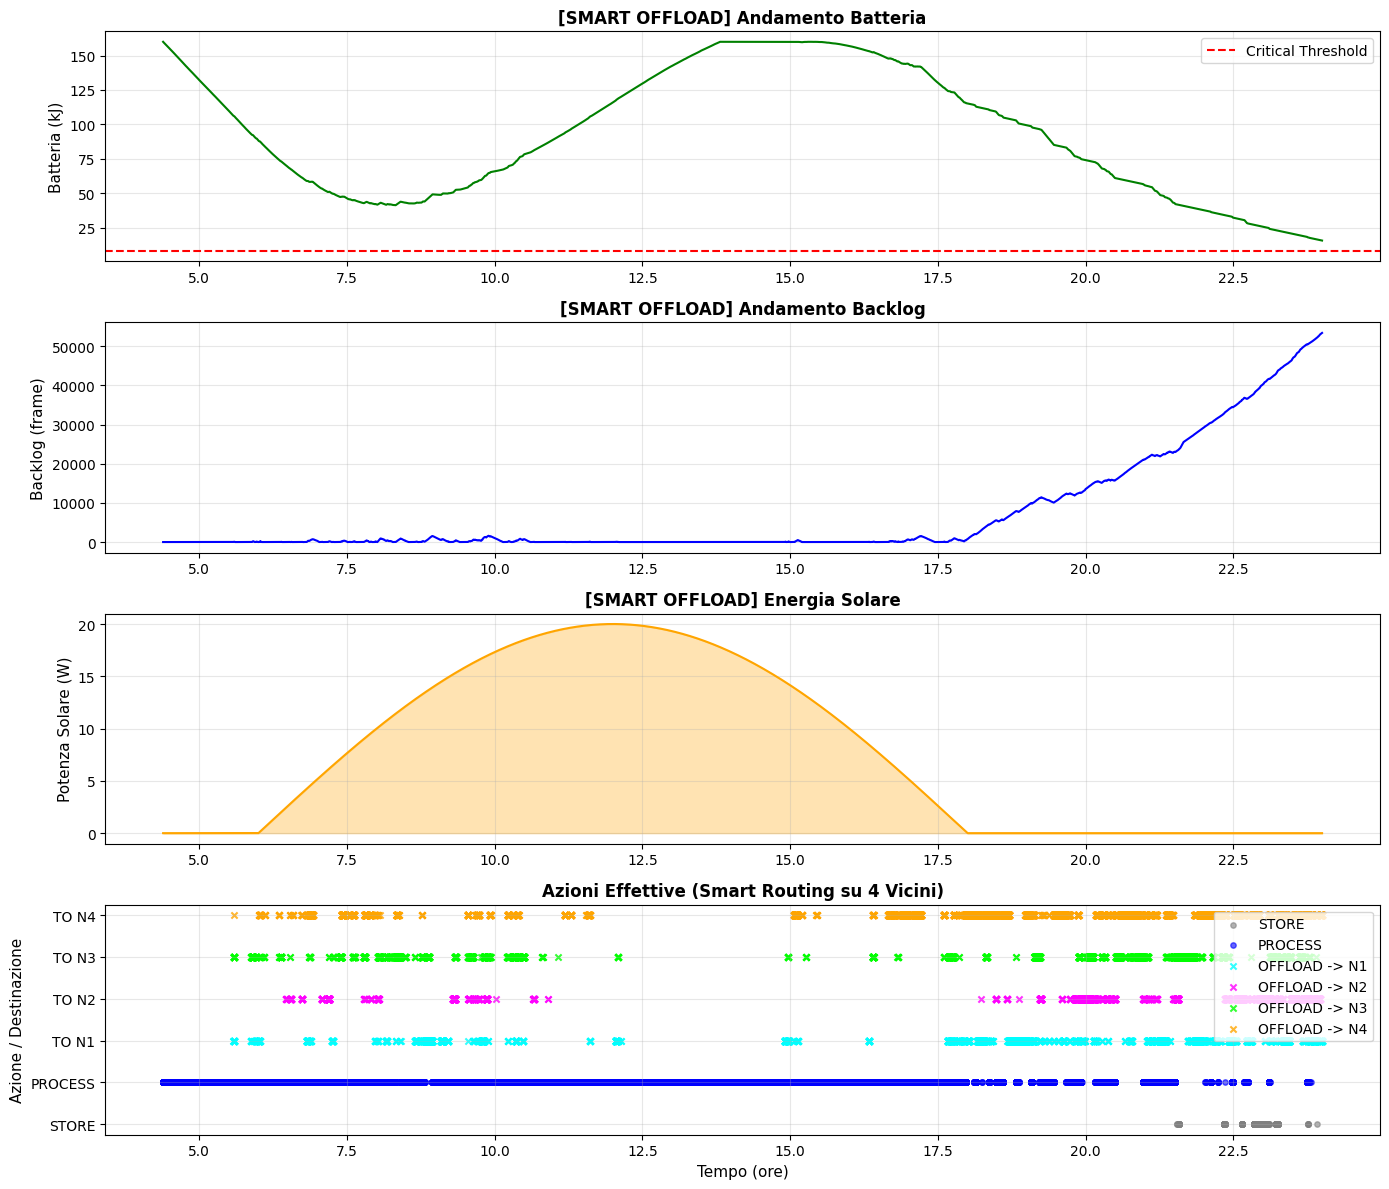

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# --- 1. CLASSE ENVIRONMENT CON SMART HISTORY ---
# Estendiamo la tua classe base per aggiungere solo il salvataggio storico del target
class SolarEdgeEnvWithSmartHistory(SolarEdgeEnv):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Inizializza history extra per tracciare il target reale
        self.history['real_offload_target'] = []

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        self.history['real_offload_target'] = []
        return obs, info

    def step(self, action):
        # 1. Identifica il target PRIMA di eseguire lo step (per coerenza temporale)
        real_target_idx = -1

        # Se l'azione è Offload (>= 2), la classe base userà _get_best_neighbor.
        # Noi lo chiamiamo qui solo per sapere CHI sarà il target e salvarlo nel grafico.
        if action >= 2:
            real_target_idx = self._get_best_neighbor()

        # 2. Esegui lo step originale (che userà internamente _get_best_neighbor)
        obs, reward, terminated, truncated, info = super().step(action)

        # 3. Salva il target nella history
        self.history['real_offload_target'].append(real_target_idx)

        return obs, reward, terminated, truncated, info


# --- 2. FUNZIONE PLOTTING SMART ---
def plot_results_smart(env, title_prefix=""):
    """
    Genera grafici usando i dati REALI di destinazione offload
    (basati sulla Smart Logic, non sull'azione raw dell'agente).
    """
    history = env.history
    if not history['time']:
        print("Nessun dato storico.")
        return

    time_hours = np.array(history['time']) / 3600.0

    # Recuperiamo i target reali salvati durante la simulazione
    if 'real_offload_target' in history:
        real_targets = np.array(history['real_offload_target'])
    else:
        print("ATTENZIONE: Dati 'real_offload_target' mancanti.")
        real_targets = np.full(len(time_hours), -1)

    fig, axes = plt.subplots(4, 1, figsize=(14, 12))

    # --- A. Batteria ---
    axes[0].plot(time_hours, np.array(history['battery']) / 1000, linewidth=1.5, color='green')
    axes[0].set_ylabel('Batteria (kJ)', fontsize=11)
    axes[0].set_title(f'{title_prefix}Andamento Batteria', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    crit = getattr(env, 'critical_battery_j', 0)
    axes[0].axhline(y=crit/1000, color='r', linestyle='--', label='Critical Threshold')
    axes[0].legend()

    # --- B. Backlog ---
    axes[1].plot(time_hours, history['backlog'], linewidth=1.5, color='blue')
    axes[1].set_ylabel('Backlog (frame)', fontsize=11)
    axes[1].set_title(f'{title_prefix}Andamento Backlog', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    # --- C. Solare ---
    axes[2].plot(time_hours, history['solar_power'], linewidth=1.5, color='orange')
    axes[2].set_ylabel('Potenza Solare (W)', fontsize=11)
    axes[2].set_title(f'{title_prefix}Energia Solare', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].fill_between(time_hours, 0, history['solar_power'], alpha=0.3, color='orange')

    # --- D. Azioni (SMART) ---
    actions = np.array(history['action'])
    sleep_mask = np.array(history['sleep_mode'])
    num_neighbors = getattr(env, 'num_neighbors', 2)

    # Tagliamo gli array alla lunghezza minima
    L = min(len(time_hours), len(actions), len(real_targets))
    time_hours = time_hours[:L]
    actions = actions[:L]
    sleep_mask = sleep_mask[:L]
    real_targets = real_targets[:L]

    # 1. Plot STORE (Action 0)
    mask_store = (actions == 0) & (~sleep_mask)
    if mask_store.any():
        axes[3].scatter(time_hours[mask_store], actions[mask_store],
                        label='STORE', color='gray', alpha=0.6, s=15)

    # 2. Plot PROCESS (Action 1)
    mask_proc = (actions == 1) & (~sleep_mask)
    if mask_proc.any():
        axes[3].scatter(time_hours[mask_proc], actions[mask_proc],
                        label='PROCESS', color='blue', alpha=0.6, s=15)

    # 3. Plot OFFLOAD (Action >= 2) - DIVISI PER NODO REALE
    colors = ['cyan', 'magenta', 'lime', 'orange'] # Colori per i vicini

    for i in range(num_neighbors):
        # La condizione è: L'agente voleva fare offload (action >= 2)
        # E la logica smart ha scelto il vicino 'i' (real_targets == i)
        mask_off = (actions >= 2) & (real_targets == i) & (~sleep_mask)

        if mask_off.any():
            # Mettiamo tutti su livelli distinti y=2+i
            y_vals = np.full(mask_off.sum(), 2 + i)
            axes[3].scatter(time_hours[mask_off], y_vals,
                          label=f'OFFLOAD -> N{i+1}', color=colors[i % len(colors)],
                          alpha=0.8, s=20, marker='x')

    # Evidenzia Sleep
    if sleep_mask.any():
        axes[3].fill_between(time_hours, -0.5, 2 + num_neighbors,
                            where=sleep_mask, alpha=0.2, color='red', label='Sleep Mode')

    axes[3].set_ylabel('Azione / Destinazione', fontsize=11)
    axes[3].set_xlabel('Tempo (ore)', fontsize=11)
    axes[3].set_title(f'Azioni Effettive (Smart Routing su {num_neighbors} Vicini)', fontsize=12, fontweight='bold')

    # Tick personalizzati
    y_ticks = [0, 1] + [2 + i for i in range(num_neighbors)]
    y_labels = ['STORE', 'PROCESS'] + [f'TO N{i+1}' for i in range(num_neighbors)]
    axes[3].set_yticks(y_ticks)
    axes[3].set_yticklabels(y_labels)
    axes[3].grid(True, alpha=0.3)
    axes[3].legend(loc='upper right', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()


# --- 3. ESECUZIONE SIMULAZIONE ---
# Configurazione
N_NEIGHBORS = 4
SIM_DAYS = 1
SIM_STEPS = SIM_DAYS * 24 * 3600

print(f"Avvio simulazione con Smart Offload ({N_NEIGHBORS} vicini)...")

if 'model_trained' not in globals():
    print("ERRORE: 'model_trained' non trovato. Carica il modello prima di eseguire.")
else:
    # Setup Ambiente
    env_smart = SolarEdgeEnvWithSmartHistory(num_neighbors=N_NEIGHBORS, sim_seconds=SIM_STEPS)

    obs, _ = env_smart.reset(seed=42)

    for _ in range(SIM_STEPS):
        action, _ = model_trained.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env_smart.step(int(action))

        if terminated or truncated:
            break

    print("Simulazione terminata.")
    # Statistiche
    print("\n=== STATISTICHE POLICY PPO ===")
    print(f"Frame arrivati: {env_smart.total_frames_arrived}")
    print(f"Frame processati: {env_smart.total_frames_processed}")
    print(f"Frame droppati: {env_smart.total_frames_dropped}")
    print(f"Frame offloadati: {env_smart.total_frames_offloaded}")
    print(f"Step in sleep mode: {env_smart.sleep_steps}")
    print(f"Batteria finale: {env_smart.battery_j / 1000:.2f} kJ")
    print(f"Backlog finale: {env_smart.backlog}")
    plot_results_smart(env_smart, title_prefix="[SMART OFFLOAD] ")

---

## Conclusioni

Questo notebook ha implementato e testato tre approcci per la gestione energetica di un nodo edge:

1. **Policy Random**: Baseline casuale per riferimento
2. **Policy Euristica**: Regole deterministiche basate su soglie
3. **Policy PPO**: Apprendimento per rinforzo con ottimizzazione a lungo termine

**Obiettivo principale**: Minimizzare gli step in sleep mode (che causano perdita di frame) mantenendo batteria stabile e backlog controllato.

**Risultati attesi**:
- Random: performance baseline, molti sleep step
- Euristica: miglioramento significativo, gestione reattiva
- PPO: ottimizzazione proattiva, anticipa pattern solari e di carico

L'agente PPO addestrato può essere esportato e utilizzato per deployment in sistemi reali.